# Emilio León
## Ejercicio IRIS
### 23/03/2026

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, classification_report
import matplotlib.pyplot as plt

In [4]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
datos = iris.data
target = iris.target

In [6]:
X = pd.DataFrame(datos, columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])

In [7]:
y = pd.Series(target)
y.sample(5)

35     0
78     1
73     1
110    2
140    2
dtype: int64

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [9]:
X.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: None
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB


In [11]:
y.describe()

count    150.000000
mean       1.000000
std        0.819232
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        2.000000
dtype: float64

In [ ]:
# El objetivo (y) es la clase de IRIS (hay tres clases)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [13]:
dtc = tree.DecisionTreeClassifier()
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [14]:
cv_scores = cross_val_score(dtc, X, y, cv=10)
cv_scores

array([1.        , 0.93333333, 1.        , 0.93333333, 0.93333333,
       0.86666667, 0.93333333, 1.        , 1.        , 1.        ])

In [15]:
cv_scores.mean(), cv_scores.std()

(np.float64(0.96), np.float64(0.044221663871405324))

In [1]:
# La media de el acurracy en cada fold es muy bueno, pues en casi todos es de 1.
# Mientras que la desviación estándar es muy bueno también pues es del 4% (mucho menor al 30)

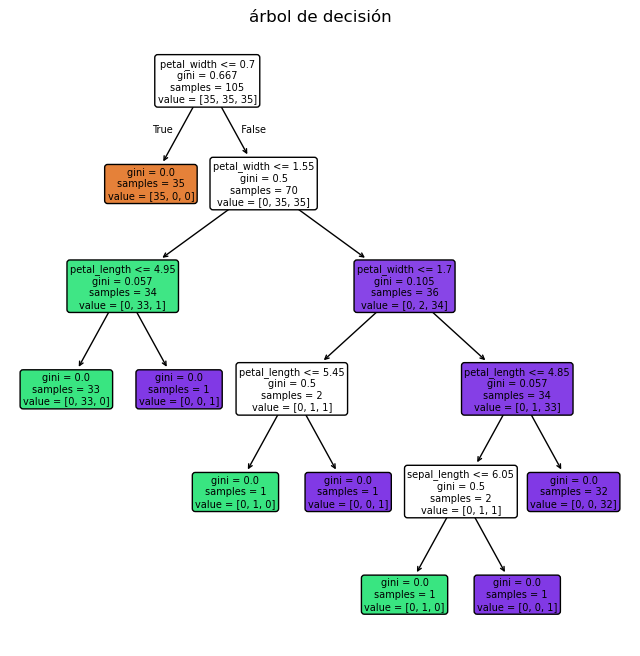

In [17]:
plt.figure(figsize = (8,8))
tree.plot_tree(dtc, feature_names=X.columns, filled=True, rounded=True)
plt.title("árbol de decisión")
plt.show()

In [18]:
dtc.get_depth()

5

## Hay 5 ramas en el árbol

In [19]:
dtc.get_n_leaves()

np.int64(8)

### Hay 8 hojas en el árbol

In [20]:
y_pred = dtc.predict(X_test)

In [21]:
confusion_matrix(y_test, y_pred)

array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  2, 13]])

In [22]:
accuracy_score(y_test, y_pred)

0.9333333333333333

### Es muy bueno el módelo pues tuvo 3 errores en tótla.